### import dependencies

In [28]:
import tensorflow as tf
from tensorflow.keras import models, layers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix


### load data and Visualize

Parameters for tunning

In [2]:
IMAGE_SIZE = 256
BATCH_SIZE = 32
CHANNELS   = 3
EPOCHS     = 30

load data

In [3]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(
            directory = "D:\download_99\Dreams\Ai_Roadmap\DL_Projects\PRJ-003_Potato_Disease_CNN\Data",
            shuffle = True,
            image_size = (IMAGE_SIZE,IMAGE_SIZE)
)

Found 2152 files belonging to 3 classes.


In [4]:
class_names = dataset.class_names
class_names

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']

visualize data

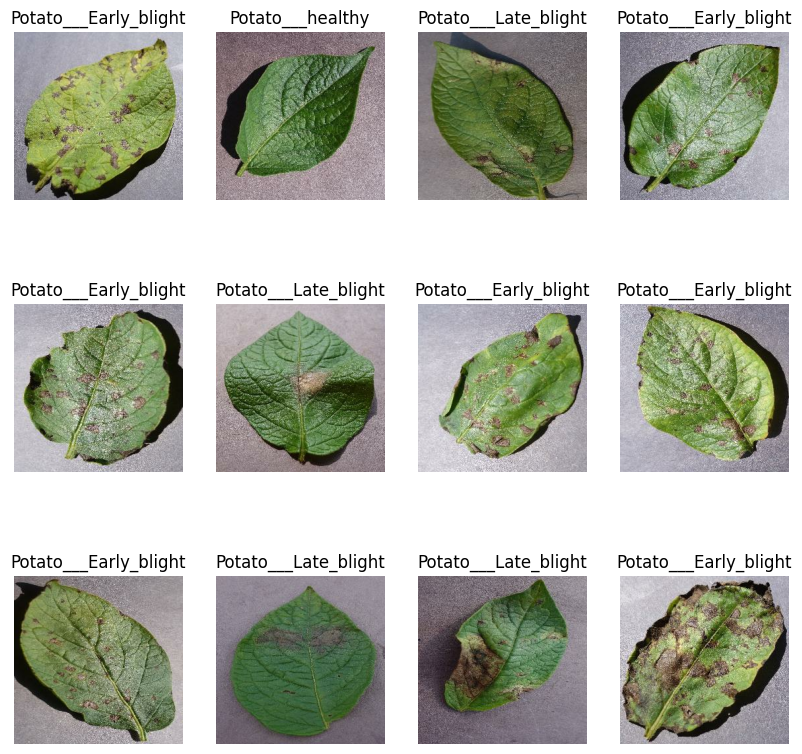

In [5]:
plt.figure(figsize = (10,10))
for image_batch, label_batch in dataset.take(1):
    for i in range(12):
        ax = plt.subplot(3,4,i+1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.title(class_names[label_batch[i]])
        plt.axis("off")

In [6]:
len(dataset)

68

### split data

80% ==> training

20% ==> 10% validation, 10% test

In [7]:
def get_dataset_partitions(ds, train_split=0.8, val_split=0.1, test_split=0.1, shuffle=True ,shuffle_size = 10000):

    ds_size = len(ds)

    if shuffle:
        ds = ds.shuffle(shuffle_size, seed =12) 
        
    train_size = int(train_split * ds_size)
    val_size   = int(val_split   * ds_size)

    train_ds = ds.take(train_size)
    val_ds   = ds.skip(train_size).take(val_size)
    test_ds  = ds.skip(train_size + val_size)

    return train_ds, val_ds, test_ds

train_ds, val_ds, test_ds = get_dataset_partitions(dataset)

print(f"Train batches : {len(train_ds)}")
print(f"Val batches   : {len(val_ds)}")
print(f"Test batches  : {len(test_ds)}")

Train batches : 54
Val batches   : 6
Test batches  : 8


just for performance

In [8]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds  = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

### preprocessing

In [9]:
# normalization — applied to all splits
resize_and_rescale = tf.keras.Sequential([
    layers.Rescaling(1.0 / 255)
])

# augmentation — applied to TRAIN ONLY
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2)
])

### Model build

In [10]:
input_shape = (IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
n_classes   = len(class_names)

model = models.Sequential([
    layers.Input(shape=input_shape),

    resize_and_rescale,
    data_augmentation,

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(n_classes, activation='softmax'),
])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 277,891 (1.06 MB)

 Trainable params: 277,891 (1.06 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# compilling the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# stops training when val_loss doesn't improve for 5 epochs
early_stopping = EarlyStopping(
    monitor              = 'val_loss',
    patience             = 5,
    restore_best_weights = True,   # rolls back to best epoch automatically
    verbose              = 1
)

# saves the best model to disk automatically
checkpoint = ModelCheckpoint(
    filepath        = 'best_model.keras',
    monitor         = 'val_loss',
    save_best_only  = True,
    verbose         = 1
)


In [12]:
history = model.fit(
    train_ds,
    epochs = EPOCHS,
    batch_size = BATCH_SIZE,
    verbose = 1,
    validation_data = val_ds,
    callbacks       = [early_stopping, checkpoint]
)

Epoch 1/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 679ms/step - accuracy: 0.4850 - loss: 0.9116
Epoch 1: val_loss improved from None to 0.47117, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
54/54 ━━━━━━━━━━━━━━━━━━━━ 42s 723ms/step - accuracy: 0.5943 - loss: 0.7893 - val_accuracy: 0.7969 - val_loss: 0.4712
Epoch 2/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 674ms/step - accuracy: 0.8132 - loss: 0.4423
Epoch 2: val_loss improved from 0.47117 to 0.22358, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
54/54 ━━━━━━━━━━━━━━━━━━━━ 37s 691ms/step - accuracy: 0.8426 - loss: 0.3949 - val_accuracy: 0.8854 - val_loss: 0.2236
Epoch 3/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 724ms/step - accuracy: 0.8774 - loss: 0.3151
Epoch 3: val_loss improved from 0.22358 to 0.13750, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
54/54 ━━━━━━━━━━━━━━━━━━━━ 40s 740ms/step - accuracy: 0.8866 - loss: 0.2980 - val_accuracy: 0.9427

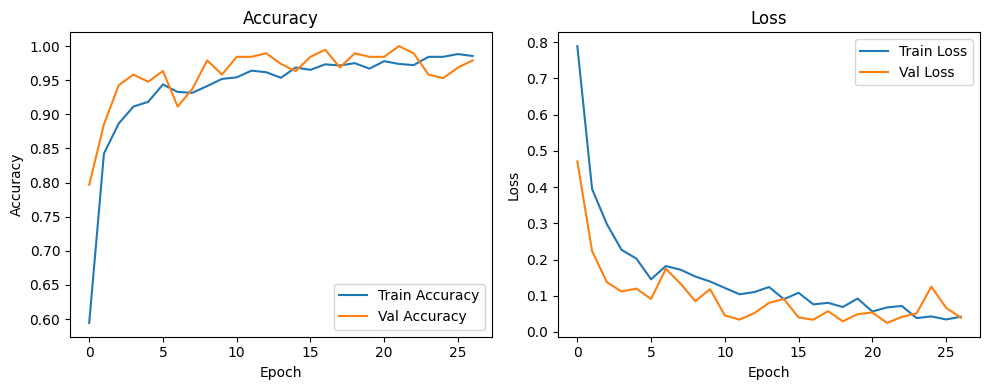

In [13]:
# accuracy curves
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'],     label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy')

# loss curves
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'],     label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss')

plt.tight_layout()
plt.show()

### model evaluation

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 122ms/step - accuracy: 0.9883 - loss: 0.0531
Test Loss     : 0.05
Test Accuracy : 0.99
                       precision    recall  f1-score   support

Potato___Early_blight       1.00      0.99      1.00       117
 Potato___Late_blight       0.99      0.98      0.99       124
     Potato___healthy       0.88      1.00      0.94        15

             accuracy                           0.99       256
            macro avg       0.96      0.99      0.97       256
         weighted avg       0.99      0.99      0.99       256



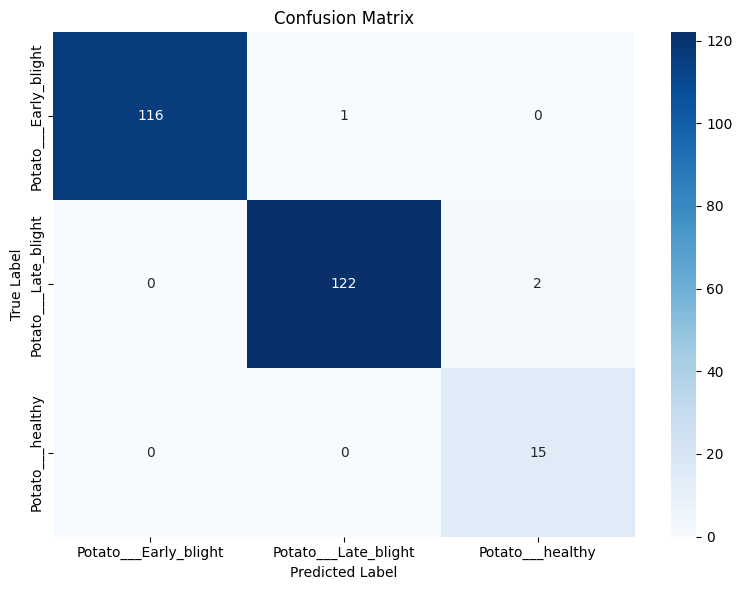

In [29]:
# 1 — basic metrics
scores = model.evaluate(test_ds)
print(f'Test Loss     : {scores[0]:.2f}')
print(f'Test Accuracy : {scores[1]:.2f}')

# 2 — collect predictions
y_true, y_pred = [], []
for image_batch, label_batch in test_ds:
    preds = model.predict(image_batch, verbose=0)
    y_true.extend(label_batch.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

# 3 — classification report
print(classification_report(y_true, y_pred, target_names=class_names))

# 4 — confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

### prediction system

In [ ]:
def predict(model, img, threshold=0.7):
    # convert and add batch dimension
    img_array = tf.keras.preprocessing.image.img_to_array(img.numpy())
    img_array = tf.expand_dims(img_array, 0)

    # get predictions
    predictions   = model.predict(img_array, verbose=0)
    confidence = float(f"{100 * np.max(predictions[0]):.2f}")
    predicted_class = class_names[np.argmax(predictions[0])]   # to convert the pred [0.9,0.5,0.2] to the max so the class is 1

    # reject low confidence predictions
    if confidence < (threshold * 100):
        return "Unknown — Not a potato leaf image", confidence

    return predicted_class, confidence

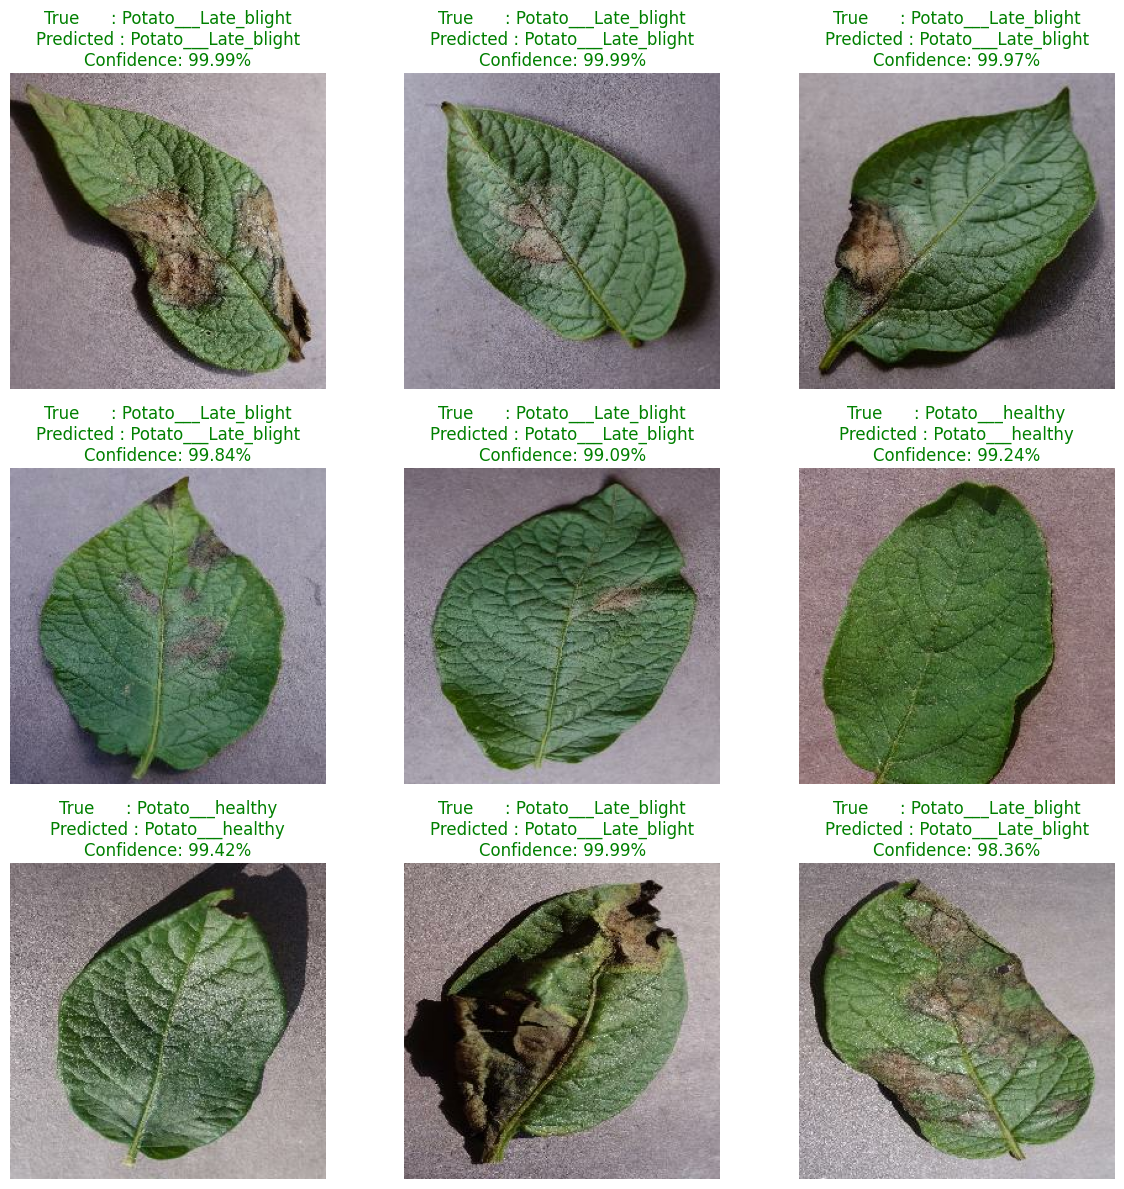

In [27]:
plt.figure(figsize=(12, 12))
for image_batch, label_batch in test_ds.take(1):
    for i in range(9):
        ax         = plt.subplot(3, 3, i + 1)
        predicted_class, confidence = predict(model, image_batch[i])
        true       = class_names[label_batch[i]]
        color      = 'green' if true == predicted_class else 'red'

        plt.imshow(image_batch[i].numpy().astype('uint8'))
        plt.title(f'True      : {true}\n'
                  f'Predicted : {predicted_class}\n'
                  f'Confidence: {confidence:.2f}%', color=color)
        plt.axis('off')

plt.tight_layout()
plt.show()

### model save

In [44]:
import os

model_name = 'v1_acc99.keras'
save_dir = "D:/download_99/Dreams/Ai_Roadmap/DL_Projects/PRJ-003_Potato_Disease_CNN/saved_model"

# Create directory if it doesn't exist
os.makedirs(save_dir, exist_ok=True)

# Save model as tf
model.save(f"{save_dir}/{model_name}")
print(f"Model saved to {save_dir}/{model_name}")

Model saved to D:/download_99/Dreams/Ai_Roadmap/DL_Projects/PRJ-003_Potato_Disease_CNN/saved_model/v1_acc99.keras
